# Machine Learning - Exercise 1
# Classification Evaluation

This exercise illustrates examples of evaluation of solutions of classification problems.

##Import

Import libraries that contains the implementations of the functions used in the rest of the program.



In [2]:
import random
import numpy as np
import sklearn.metrics
from sklearn import datasets
from sklearn.model_selection import train_test_split, cross_val_score, ShuffleSplit, GridSearchCV
from sklearn import svm
from sklearn import tree
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.multiclass import unique_labels
import matplotlib.pyplot as plt

def plot_confusion_matrix(y_true, y_pred, classes,
                          normalize=False,
                          title=None,
                          cmap=plt.cm.Blues): # try cmap=plt.cmap.YlOrBr
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if not title:
        if normalize:
            title = 'Normalized confusion matrix'
        else:
            title = 'Confusion matrix, without normalization'

    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    # Only use the labels that appear in the data
    classes = classes[unique_labels(y_true, y_pred)]
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    fig, ax = plt.subplots()
    im = ax.imshow(cm, interpolation='nearest', cmap=cmap)
    ax.figure.colorbar(im, ax=ax)
    # We want to show all ticks...
    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           # ... and label them with the respective list entries
           xticklabels=classes, yticklabels=classes,
           title=title,
           ylabel='True label',
           xlabel='Predicted label')

    ax.set_ylim(len(classes)-0.5, -0.5)

    # Rotate the tick labels and set their alignment.
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right",
             rotation_mode="anchor")

    # Loop over data dimensions and create text annotations.
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], fmt),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")
    fig.tight_layout()
    return ax

print("Libraries imported.")

Libraries imported.


## Load data

Load training data.

Choose one of the datasets described in the next subsections.

More details on these datasets are available in https://scikit-learn.org/stable/datasets/toy_dataset.html


### IRIS dataset

In [ ]:
DB = datasets.load_iris()
dataset_name = "Iris"
class_names = np.array([str(c) for c in DB.target_names])
X_all = DB.data
y_all = DB.target

### Wine dataset

In [ ]:
DB = datasets.load_wine()
dataset_name = "Wines"
class_names = np.array([str(c) for c in DB.target_names])
X_all = DB.data
y_all = DB.target

###Digits dataset

In [3]:
DB = datasets.load_digits()
dataset_name = "Digits"
class_names = np.array([str(c) for c in DB.target_names])
X_all = DB.data
y_all = DB.target

###Unbalanced Digits dataset

Adapted from the Digits dataset with digit 0 mapped to class '0' and all other digits mapped to class '1'

In [ ]:
# Binary Digits unbalanced
DB = datasets.load_digits()
dataset_name = "Digits_01_unbalanced"
class_names = np.array(["0","1"])
X_all = DB.data
y_all = DB.target
cont = 0
for i in range(0,len(y_all)):
  if y_all[i] != 0:
    y_all[i] = 1
    cont += 1
print("Percentage of non-zero digits: %f" %(cont/len(y_all)))

Percentage of non-zero digits: 0.900946


###Summary of the dataset

Print some information about the dataset.

Data structures

    Input X: array ( n x m )
    Output Y: array ( n x 1 )

In [4]:
print("Dataset: %s" %(dataset_name))
print("Input shape: %s" %str(X_all.shape))
print("Output shape: %s" %str(y_all.shape))
print("Number of attributes/features: %d" %(X_all.shape[1]))
print("Number of classes: %d %s" %(len(class_names), str(class_names)))
print("Number of samples: %d" %(X_all.shape[0]))

Dataset: Digits
Input shape: (1797, 64)
Output shape: (1797,)
Number of attributes/features: 64
Number of classes: 10 ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9']
Number of samples: 1797


### Show an example

Display a random sample.

In [5]:
id = random.randrange(0,X_all.shape[0])

print("x%d = %r" %(id,X_all[id]))
print("y%d = %r ['%s']" %(id,y_all[id],class_names[y_all[id]]))

x748 = array([ 0.,  0., 10., 16., 16., 13.,  0.,  0.,  0.,  4., 16., 15., 12.,
        4.,  0.,  0.,  0.,  8., 16.,  4.,  0.,  0.,  0.,  0.,  0.,  4.,
       16., 11.,  6.,  1.,  0.,  0.,  0.,  0.,  8., 16., 16., 13.,  2.,
        0.,  0.,  0.,  0.,  1.,  7., 14., 12.,  0.,  0.,  0.,  0.,  6.,
       13., 16., 10.,  0.,  0.,  0., 12., 16., 14.,  6.,  0.,  0.])
y748 = 5 ['5']


Visualize the random sample.

In [21]:
def plot_sample (sample, size):
  image = np.reshape(sample, size)
  # print(image)

  plt.imshow(image, interpolation='nearest', cmap='Greys')
  plt.show()

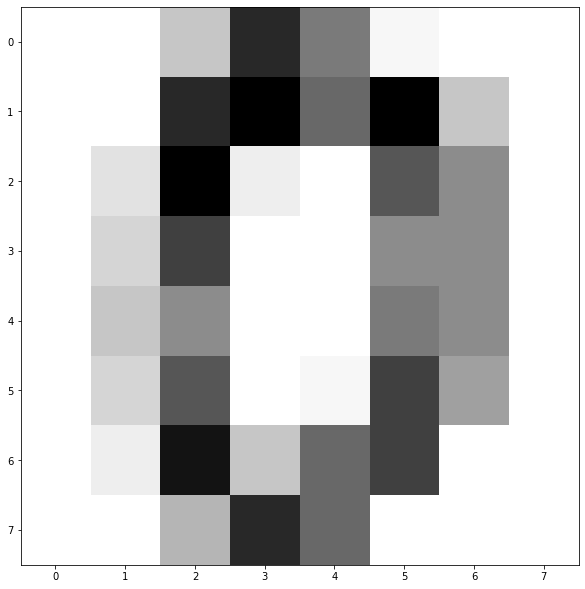

In [22]:
plot_sample(X_all[id], (-1, 8))


##Split data

Split the data set in training set `X_train`, `y_train` and test set `X_test`, `y_test`, using `test_size` to denote percentage of samples in the test set.

Note:
`random_state` parameter is used as random seed. Change this value to generate a different split.

IMPORTANT: solution will depend on this data split.


Size of training set: 1198
Size of test set: 599
First training sample
    x_train_0 = array([ 0.,  0.,  1., 13.,  4.,  0.,  0.,  0.,  0.,  0.,  5., 15.,  2.,
        0.,  0.,  0.,  0.,  0., 12.,  7.,  0.,  0.,  0.,  0.,  0.,  0.,
       14.,  6.,  0.,  0.,  0.,  0.,  0.,  0., 16., 12., 15., 15.,  7.,
        0.,  0.,  0., 14., 14.,  6.,  4., 14.,  1.,  0.,  0.,  9., 14.,
        3.,  4., 14.,  2.,  0.,  0.,  1.,  7., 14., 16., 11.,  0.])
    y_train_0 = 6 ['6']


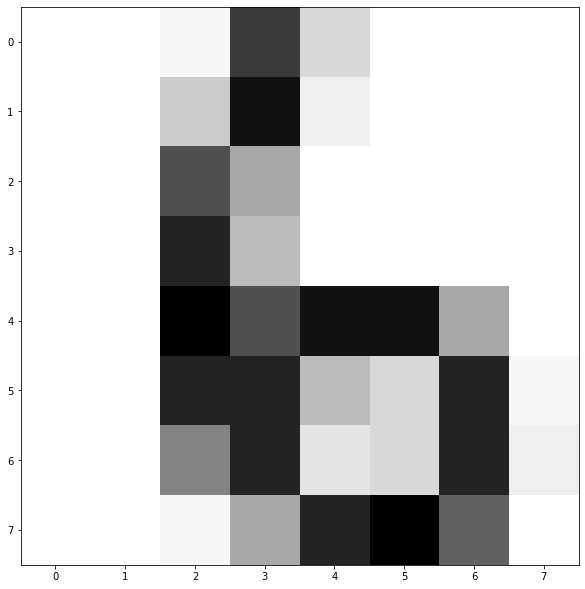

First test sample
    x_test_0 = array([ 0.,  0.,  0.,  8., 13.,  0.,  0.,  0.,  0.,  0.,  0., 14.,  6.,
        0.,  0.,  0.,  0.,  0.,  6., 12.,  0.,  0.,  0.,  0.,  0.,  0.,
        8., 13.,  8.,  2.,  0.,  0.,  0.,  0., 13., 16., 13., 14.,  4.,
        0.,  0.,  0., 11.,  8.,  2.,  3., 13.,  0.,  0.,  0.,  7., 11.,
        5., 12., 11.,  0.,  0.,  0.,  1., 11., 12.,  4.,  0.,  0.])
    y_test_0 = 6 ['6']


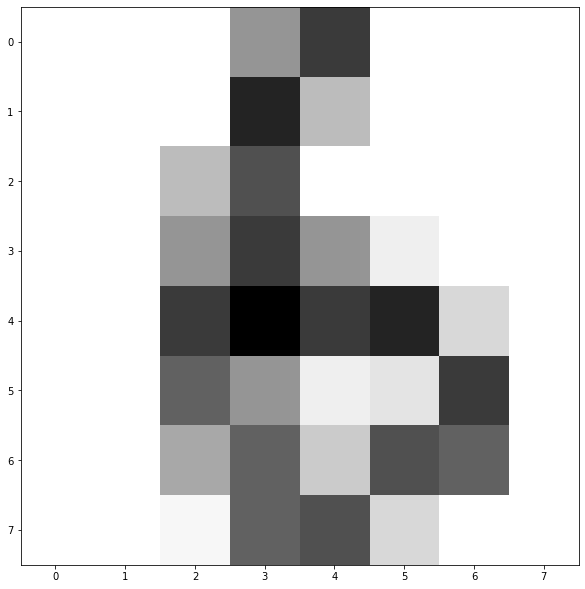

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.333,
                                                    random_state=117)

print("Size of training set: %d" %X_train.shape[0])
print("Size of test set: %d" %X_test.shape[0])

print('First training sample')
id = 0
print("    x_train_%d = %r" %(id,X_train[id]))
print("    y_train_%d = %r ['%s']" %(id,y_train[id],class_names[y_train[id]]))
plot_sample(X_train[id], (-1, 8))

print('First test sample')
id = 0
print("    x_test_%d = %r" %(id,X_test[id]))
print("    y_test_%d = %r ['%s']" %(id,y_test[id],class_names[y_test[id]]))
plot_sample(X_test[id], (-1, 8))


##Create a Model

Define the model that will be used for learning.

Create an instance of a class implementing a classification method.



**Decision Trees**

https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html#sklearn.tree.DecisionTreeClassifier

In [26]:
model = tree.DecisionTreeClassifier()

**Support Vector Machines**

https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html?highlight=svm%20svc#sklearn.svm.SVC

In [ ]:
model = svm.SVC(kernel='linear', C=1)


Probabilistic generative model

**Gaussian Naive Bayes**

https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.GaussianNB.html?highlight=gaussiannb#sklearn.naive_bayes.GaussianNB


In [ ]:
model = GaussianNB()

Probabilistic discriminative model

**Logistic regression**

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html?highlight=logisticregression#sklearn.linear_model.LogisticRegression


In [ ]:
model = LogisticRegression()

## Fit the model

Finding a solution for this model given the data set.
The solution is stored in the model object.


In [27]:
model.fit(X_train, y_train)

DecisionTreeClassifier()

### Plot the decision tree


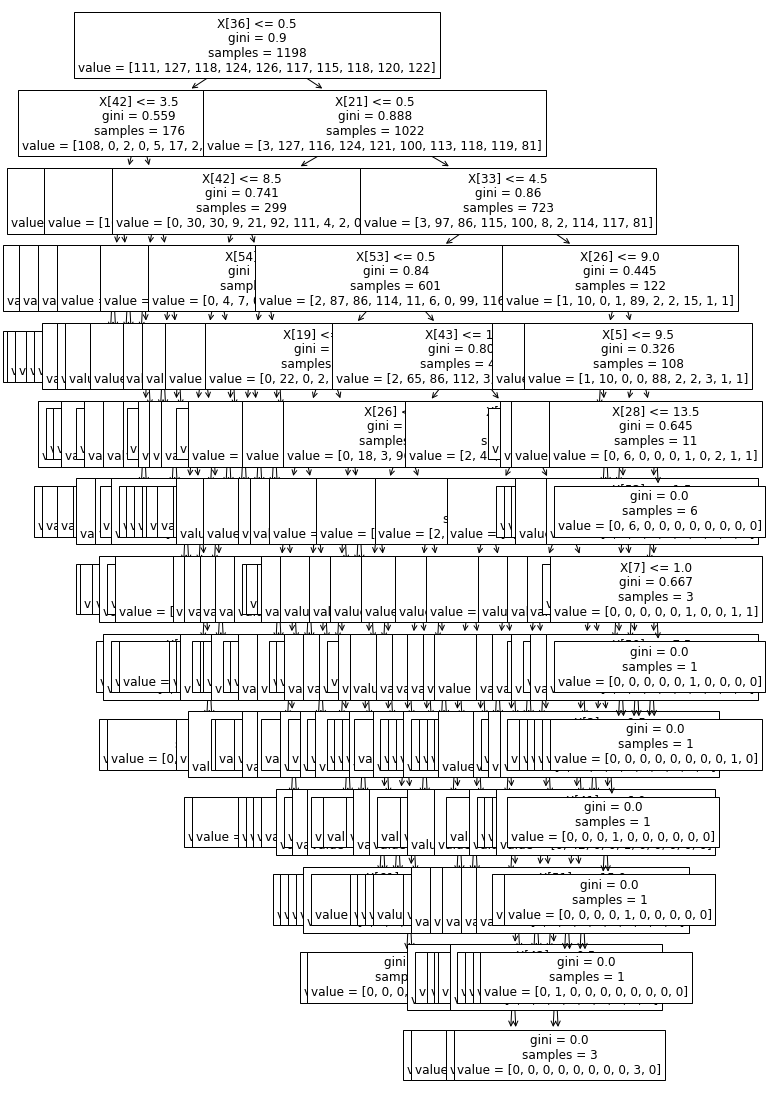

In [28]:
# only for DecisionTress model

if isinstance(model, tree.DecisionTreeClassifier):
  tree.plot_tree(model,fontsize=12)
  plt.rcParams["figure.figsize"] = (10,20)
  plt.show()

##Predict on test set

Use test set for prediction.

In [32]:
y_pred = model.predict(X_test)
print(y_pred)

[6 1 0 0 4 7 9 3 6 0 1 6 3 8 0 3 2 9 7 8 0 8 2 6 0 3 0 1 7 3 5 9 1 0 6 0 6
 1 6 4 8 1 7 4 7 4 8 1 4 0 0 3 8 1 8 0 1 0 8 3 9 3 0 8 8 3 0 1 1 0 8 4 5 9
 3 5 2 9 1 4 5 2 0 6 8 1 3 6 8 9 0 4 8 7 1 7 1 0 6 4 9 5 7 0 9 8 4 6 2 6 7
 4 1 2 6 6 9 5 7 2 0 3 2 9 0 3 5 5 7 5 3 0 2 2 9 6 1 6 8 0 2 9 3 0 9 7 4 7
 8 6 7 9 0 0 1 5 5 3 9 0 8 0 7 1 5 8 2 1 1 5 2 1 1 1 6 7 0 5 6 3 2 7 9 2 6
 5 2 5 7 2 7 6 2 5 2 1 0 4 0 2 7 3 3 8 4 9 6 9 3 3 3 5 4 5 4 9 4 9 4 0 4 4
 6 0 0 0 5 6 6 3 7 7 0 5 3 8 1 8 3 4 8 4 9 3 2 4 8 7 8 6 2 0 0 3 7 0 8 6 1
 3 0 7 6 5 2 6 0 2 5 0 4 6 6 2 1 7 9 1 8 6 7 7 4 8 2 6 3 0 3 6 3 2 6 3 6 5
 2 4 9 3 3 5 6 1 7 2 9 2 0 8 7 3 5 9 9 9 2 7 9 9 0 1 6 0 7 7 5 7 4 9 3 6 2
 1 8 7 9 7 9 9 8 2 0 0 3 5 2 8 7 8 5 0 2 5 9 0 3 7 3 1 1 7 2 5 5 2 0 9 7 7
 7 3 9 1 0 0 6 3 3 3 1 5 4 8 7 5 4 5 5 1 3 0 7 1 5 9 4 6 2 2 0 6 5 1 4 3 5
 7 0 8 8 9 3 6 4 6 8 3 8 1 3 6 4 1 9 0 6 8 5 5 5 1 6 0 3 9 6 3 0 2 8 9 2 3
 1 3 3 2 6 8 6 9 4 3 1 5 1 6 4 6 0 9 6 1 0 5 5 8 1 3 0 1 4 8 3 2 7 2 7 9 2
 3 9 2 0 3 1 2 8 2 5 4 2 

Use this statement to generate a prediction vector of all values '1' useful to test performance with the Unblanced Digits dataset.



In [30]:
# Result of model that predicts only 1 (for unblanced digits)
y_pred = np.ones(len(X_test))

##Evaluate the Model

Evaluation of a specific solution on the test set, comparing predicted values `y_pred` with test values `y_test`.

### Accuracy

In [33]:
acc = model.score(X_test, y_test)
print("Accuracy %.3f" %acc)

Accuracy 0.855


###Precision & Recall

Classification report contains more accurate performance information.

In [36]:
print(classification_report(y_test, y_pred, labels=None, target_names=class_names, digits=3))


              precision    recall  f1-score   support

           0      0.929     0.970     0.949        67
           1      0.803     0.891     0.845        55
           2      0.847     0.847     0.847        59
           3      0.765     0.881     0.819        59
           4      0.915     0.782     0.843        55
           5      0.932     0.846     0.887        65
           6      0.938     0.909     0.923        66
           7      0.931     0.885     0.908        61
           8      0.717     0.704     0.710        54
           9      0.767     0.793     0.780        58

    accuracy                          0.855       599
   macro avg      0.854     0.851     0.851       599
weighted avg      0.859     0.855     0.855       599



### Confusion Matrix

Shows the results in a graphical form.

[[65  0  0  0  0  1  0  0  1  0]
 [ 0 49  2  0  0  0  0  0  3  1]
 [ 0  0 50  3  0  1  2  0  2  1]
 [ 0  1  1 52  0  1  0  0  1  3]
 [ 0  4  0  0 43  0  2  1  3  2]
 [ 1  0  0  5  1 55  0  0  0  3]
 [ 0  3  0  0  1  1 60  0  1  0]
 [ 0  1  1  0  2  0  0 54  1  2]
 [ 2  3  4  3  0  0  0  2 38  2]
 [ 2  0  1  5  0  0  0  1  3 46]]
Confusion matrix, without normalization
[[65  0  0  0  0  1  0  0  1  0]
 [ 0 49  2  0  0  0  0  0  3  1]
 [ 0  0 50  3  0  1  2  0  2  1]
 [ 0  1  1 52  0  1  0  0  1  3]
 [ 0  4  0  0 43  0  2  1  3  2]
 [ 1  0  0  5  1 55  0  0  0  3]
 [ 0  3  0  0  1  1 60  0  1  0]
 [ 0  1  1  0  2  0  0 54  1  2]
 [ 2  3  4  3  0  0  0  2 38  2]
 [ 2  0  1  5  0  0  0  1  3 46]]


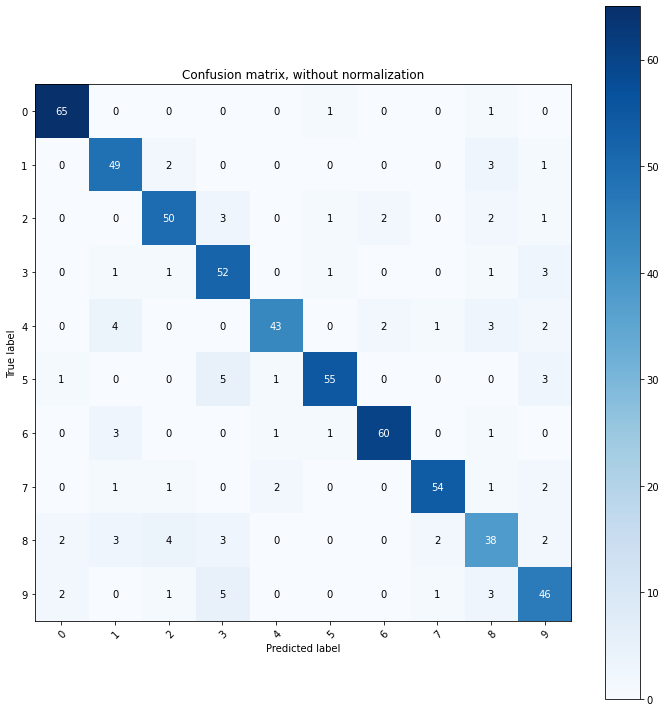

In [37]:
cm = confusion_matrix(y_test, y_pred, labels=None, sample_weight=None)
print(cm)
plt.rcParams["figure.figsize"] = (10,10)
plot_confusion_matrix(y_test, y_pred, classes=class_names, normalize=False)

## Evaluate a specific instance of a method

Evaluation of a specific method with instantiated hyper-parameters
through Cross Validation



In [38]:
#K-Fold Cross Validation
cv = ShuffleSplit(n_splits=5, test_size=0.333, random_state=15)
scores = cross_val_score(model, X_all, y_all, cv=cv)

# class sklearn.model_selection.ShuffleSplit(n_splits=10, *, test_size=None, train_size=None, random_state=None)
# Random permutation cross-validator
# Yields indices to split data into training and test sets.

print(scores)
print("Accuracy: %0.3f (+/- %0.2f)" % (scores.mean(), scores.std() * 2)) # mean and standard deviation

[0.86811352 0.82136895 0.84641068 0.82804674 0.86811352]
Accuracy: 0.846 (+/- 0.04)


## Prediction of a new sample

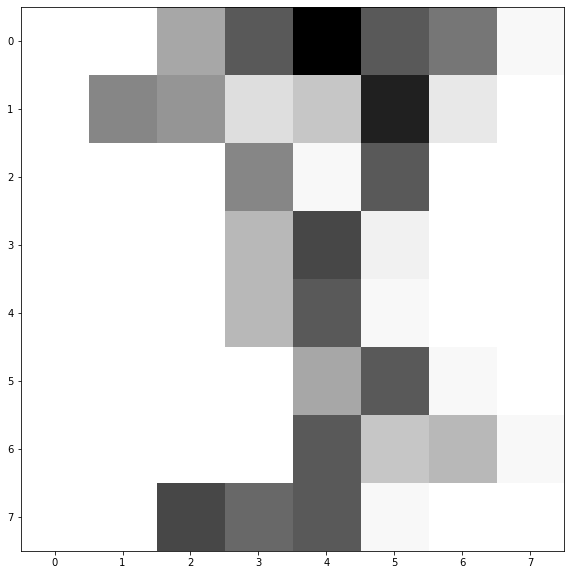

x_new = array([[ 0,  0,  8, 13, 18, 13, 11,  1,  0, 10,  9,  4,  6, 16,  3,  0,
         0,  0,  0, 10,  1, 13,  0,  0,  0,  0,  0,  7, 14,  2,  0,  0,
         0,  0,  0,  7, 13,  1,  0,  0,  0,  0,  0,  0,  8, 13,  1,  0,
         0,  0,  0,  0, 13,  6,  7,  1,  0,  0, 14, 12, 13,  1,  0,  0]])
y_pred = 8 ['8']
Confidence: 1.00


In [40]:
if dataset_name == "Iris":
  xnew = np.array([8.5, 2.6, 9.2, 0.3])
elif dataset_name == "Wines":
  xnew = np.array([12, 2.5, 2.6, 15, 186, 1.5, 9.1,
                   0.44, 2.2, 5.6, 2.9, 3.7, 380])
elif dataset_name == "Digits" or dataset_name == "Digits_01_unbalanced":
   xnew = np.array([
        0,  0,  8, 13, 18, 13, 11,  1,  0, 10,  9,  4,  6,
       16,  3,  0,  0,  0,  0, 10,  1, 13,  0,  0,  0,  0,
        0,  7, 14,  2,  0,  0,  0,  0,  0,  7, 13,  1,  0,
        0,  0,  0,  0,  0,  8, 13,  1,  0,  0,  0,  0,  0,
       13,  6,  7,  1,  0,  0, 14, 12, 13,  1,  0,  0])

xnew = xnew.reshape(1,-1)

plot_sample(xnew, (8, 8))

print("x_new = %r" %(xnew))
ynew = model.predict(xnew)
print("y_pred = %d %s" %(ynew,class_names[ynew]))

# only for probabilistic models
try:
  mconf = np.max(model.predict_proba(xnew))
  print("Confidence: %.2f" %(mconf))
except:
  pass

##Common Mistake

Evaluate solution on data used for training!!!


In [41]:
model.score(X_all,y_all)

0.9515859766277128

## Question 1

Design an evaluation procedure to assess and compare the different performance of the classifcation models seen above on the Digits dataset

In [105]:
import random
import numpy as np
import sklearn.metrics
from sklearn import datasets
from sklearn.model_selection import train_test_split, cross_val_score, ShuffleSplit, GridSearchCV

# models to compare
# from sklearn import svm
from sklearn import tree
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.multiclass import unique_labels
import matplotlib.pyplot as plt

# dataset
DB = datasets.load_digits()
dataset_name = "Digits"
class_names = np.array([str(c) for c in DB.target_names])
X_all = DB.data
y_all = DB.target

X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.333,
                                                    random_state=117)

# models

"""
models = [decision_tree, gaussian_naive_bayes]
model_names = ['decision_tree', 'gaussian_naive_bayes']
for index, model in enumerate(models):

  # fit the model
  #model.fit(X_train, y_train)

  # cross validation test
  cv = ShuffleSplit(n_splits=5, test_size=0.333, random_state=15)
  scores = cross_val_score(model, X_all, y_all, cv=cv)

  print("Accuracy for %s: %0.3f (+/- %0.2f)" % (model_names[index], scores.mean(), scores.std()))
"""

# cross validation test
cv = ShuffleSplit(n_splits=5, test_size=0.333, random_state=15)

decision_tree = tree.DecisionTreeClassifier()
decision_tree_scores = cross_val_score(decision_tree, X_all, y_all, cv=cv)
print("Accuracy for decision_tree: %0.3f (+/- %0.2f)" % (decision_tree_scores.mean(), decision_tree_scores.std()))

gaussian_naive_bayes = GaussianNB()
gaussian_naive_bayes_scores = cross_val_score(gaussian_naive_bayes, X_all, y_all, cv=cv)
print("Accuracy for gaussian_naive_bayes: %0.3f (+/- %0.2f)" % (gaussian_naive_bayes_scores.mean(), gaussian_naive_bayes_scores.std()))

logistic_regression = LogisticRegression(solver='lbfgs', max_iter=5000)
logistic_regression_scores = cross_val_score(logistic_regression, X_all, y_all, cv=cv)
print("Accuracy for logistic_regression_scores: %0.3f (+/- %0.2f)" % (logistic_regression_scores.mean(), logistic_regression_scores.std()))

Accuracy for decision_tree: 0.837 (+/- 0.02)
Accuracy for gaussian_naive_bayes: 0.825 (+/- 0.03)
Accuracy for logistic_regression_scores: 0.964 (+/- 0.01)


## Question 2

Consider the Unbalanced Digits dataset and compare one of the above classification method with the classifier that always returns the most common label in the dataset. Which performance metrics are significant in this comparison?

In [3]:
import numpy as np
from sklearn.base import RegressorMixin

In [137]:
class NullRegressor(RegressorMixin):

  def fit(self, X=None, y=None):
    # The prediction will always just be the mean of y
    self.y_bar_ = np.mean(y)

  def predict(self, X=None):
    # Give back the mean of y, in the same
    # length as the number of X observations
    return np.ones(X.shape[0]) * self.y_bar_

In [4]:
class MostCommonRegressor(RegressorMixin):

  def count_values (self, data):
    class_count = {}
    for key in data:
      class_name = str(key)
      if class_count.get(class_name, None) is None:
        class_count[class_name] = 1
      else:
        class_count.update({class_name : class_count[class_name] + 1})

    return class_count

  """
  .fit()
  .predict()
  .score()
  .set_params()
  .get_params()
  """

  def fit(self, X=None, y=None):
    # find the most common label in the dataset
    class_count = self.count_values(y) # returns a dictionary with the count for each class

    # for some kind of reason this wont work
    # self.y_bar_ = max(class_count, key=lambda k: class_count.get(k))
    # self.y_bar_ = max(class_count, key=class_count.get)

    max_key = None
    max_value = 0
    for key, value in class_count.items():
      if value > max_value:
        max_key = key
        max_value = value

    self.y_bar_ = int(max_key)

  def predict(self, X=None):
    # always return the most common value
    return np.ones(X.shape[0]) * self.y_bar_

  def get_params(self, deep = False):
      return {}


In [13]:
import random
import numpy as np
import sklearn.metrics
from sklearn import datasets
from sklearn.model_selection import train_test_split, cross_val_score, ShuffleSplit, GridSearchCV

# models to compare
# from sklearn import svm
from sklearn import tree
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.multiclass import unique_labels
import matplotlib.pyplot as plt

# dataset
#DB = datasets.load_digits()
#dataset_name = "Digits"
#class_names = np.array([str(c) for c in DB.target_names])
#X_all = DB.data
#y_all = DB.target

# Binary Digits unbalanced
DB = datasets.load_digits()
dataset_name = "Digits_01_unbalanced"
class_names = np.array(["0","1"])
X_all = DB.data
y_all = DB.target
cont = 0
for i in range(0,len(y_all)):
  if y_all[i] != 0:
    y_all[i] = 1
    cont += 1
print("Percentage of non-zero digits: %f" %(cont/len(y_all)))

# cross validation test
cv = ShuffleSplit(n_splits=5, test_size=0.333, random_state=15)

# we know that for the unbalanced dataset the most common label is 1
# but this approach works for every dataset

# test
most_common = MostCommonRegressor()
#most_common.fit(X_train, y_train)
#most_common.predict(X_train)

# The actual MSE is simply the positive version of the number we're getting
# The unified scoring API always maximizes the score, so scores which need
# to be minimized are negated in order for the unified scoring API to work correctly.
# The score that is returned is therefore negated when it is a score that should
# be minimized and left positive if it is a score that should be maximized.
most_common_scores = cross_val_score(most_common, X_all, y_all, cv=cv, scoring='neg_mean_squared_error')
print("Accuracy for most_common: %0.3f (+/- %0.2f)" % (-most_common_scores.mean(), most_common_scores.std()))

decision_tree = tree.DecisionTreeClassifier()
decision_tree_scores = cross_val_score(decision_tree, X_all, y_all, cv=cv)
print("Accuracy for decision_tree: %0.3f (+/- %0.2f)" % (decision_tree_scores.mean(), decision_tree_scores.std()))


Percentage of non-zero digits: 0.900946
Accuracy for most_common: 0.099 (+/- 0.01)
Accuracy for decision_tree: 0.987 (+/- 0.01)
